In [2]:
import scanpy as sc
import anndata
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import scvi
import seaborn as sb

## GSE169246

In [2]:
adata_final =sc.read_h5ad("./output_0531/GSE169246/GSE169246_raw.h5ad")

In [3]:
adata_final.obs['sample'].value_counts()

sample
P019    53404
P013    45746
P025    33268
P023    30415
P007    30407
P002    29952
P004    26086
P016    25249
P010    22999
P022    22128
P012    20917
P020    20757
P005    19534
P008    19347
P024    16005
P017    15206
P018    14679
P014    12923
P011    11203
P001     9882
P028     5034
P003     4349
Name: count, dtype: int64

In [4]:
adata_final

AnnData object with n_obs × n_vars = 489490 × 27085
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location'

In [5]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/tmp/ipykernel_3052257/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [6]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("./output_0531/GSE169246/GSE169246_raw.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce, samples=samples)
sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="./output_0531/GSE169246/GSE169246_postR.h5ad")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

/usr/bin/bash: /home/lixiangyu/anaconda3/lib/libtinfo.so.6: no version information available (required by /usr/bin/bash)
/usr/bin/bash: /home/lixiangyu/anaconda3/lib/libtinfo.so.6: no version information available (required by /usr/bin/bash)
/usr/bin/bash: /home/lixiangyu/anaconda3/lib/libtinfo.so.6: no version information available (required by /usr/bin/bash)
/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [10]:
adata_final =sc.read_h5ad("./output_0531/GSE169246/GSE169246_postR.h5ad")

In [11]:
adata_final.var['mt'] = adata_final.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata_final, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [12]:
# pp
print('Number of cells before gene filter: {:d}'.format(adata_final.n_obs))
sc.pp.filter_cells(adata_final, min_genes=100)  #acc to author
sc.pp.filter_cells(adata_final, max_genes=4000) # acc to author
sc.pp.filter_genes(adata_final, min_cells=3) #acc to author

print('Number of cells before counts filter: {:d}'.format(adata_final.n_obs))

sc.pp.filter_cells(adata_final, max_counts = 20000) #acc to author


print('Number of cells beforeMT filter: {:d}'.format(adata_final.n_obs))

adata_final = adata_final[adata_final.obs['pct_counts_mt'] < 10] #acc to author
print('Number of cells after MT filter: {:d}'.format(adata_final.n_obs))


Number of cells before gene filter: 489490
Number of cells before counts filter: 486654
Number of cells beforeMT filter: 482824
Number of cells after MT filter: 482824


In [13]:
##保留原始计数
adata_final.layers["uncorrected_counts"] = adata_final.X.copy()
adata_final.layers["raw_decontXcounts"] = adata_final.layers["decontXcounts"].copy()
adata_final.X = np.around(adata_final.layers["raw_decontXcounts"].copy()).astype(int)
del adata_final.layers["decontXcounts"]
adata_final

/tmp/ipykernel_1993859/3519320560.py:2: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata_final.layers["uncorrected_counts"] = adata_final.X.copy()


AnnData object with n_obs × n_vars = 482824 × 23825
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decontX_P023_UMAP', 'decontX_P024_UMAP', 'decontX_P

In [14]:
adata_final

AnnData object with n_obs × n_vars = 482824 × 23825
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decontX_P023_UMAP', 'decontX_P024_UMAP', 'decontX_P

In [15]:
adata_final.write("./output_0531/GSE169246/GSE169246_postQC-R.h5ad")
adata_final

AnnData object with n_obs × n_vars = 482824 × 23825
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decontX_P023_UMAP', 'decontX_P024_UMAP', 'decontX_P

In [16]:
adata_final.obs['sample'].value_counts()

sample
P019    52362
P013    45080
P025    32318
P007    30220
P023    30000
P002    29354
P004    25992
P016    25082
P010    22945
P022    21436
P012    20831
P020    20034
P005    19438
P008    19076
P024    15950
P017    15129
P018    14366
P014    12908
P011    11096
P001     9858
P028     5003
P003     4346
Name: count, dtype: int64

# Prepare query data

In [2]:
adata_final = sc.read_h5ad("./output_0531/GSE169246/GSE169246_postQC-R.h5ad")
adata_final

AnnData object with n_obs × n_vars = 482824 × 23825
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decontX_P023_UMAP', 'decontX_P024_UMAP', 'decontX_P

In [3]:
ensembl_id_df = pd.read_csv("/home/lixiangyu/zr/Annotate/gene_names_to_ensembl_ALLFOUND_allfernandez_no6_withallslysz.csv")
gene_to_ensembl = dict(zip(ensembl_id_df['gene_name'], ensembl_id_df['ensembl_id']))
# Map the variable names in AnnData
adata_final.var['original_gene_names'] = adata_final.var_names
adata_final.var_names = [gene_to_ensembl[gene] if gene in gene_to_ensembl else gene for gene in adata_final.var_names]

In [4]:
import numpy as np
from scipy import sparse

X = adata_final.X

if sparse.issparse(X):
    vals = X.data
else:
    vals = X.ravel()

print("min:", vals.min())
print("max:", vals.max())
print("mean:", vals.mean())
print("has decimals:", np.any(vals[:10000] % 1 != 0))

min: 0
max: 14641
mean: 2.6725011720612364
has decimals: False


In [5]:
non_ENSG_vars = adata_final.var_names[~adata_final.var_names.str.startswith('ENSG')]

In [6]:
adata_final.var

,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,original_gene_names
ENSG00000238009,False,265,0.000543,99.945862,266.0,259,AL627309.1
ENSG00000237491,False,2644,0.005493,99.459846,2689.0,2572,AL669831.5
ENSG00000177757,False,142,0.000292,99.970990,143.0,139,FAM87B
ENSG00000225880,False,6294,0.013054,98.714172,6390.0,6128,LINC00115
ENSG00000188976,False,58222,0.132317,88.105579,64768.0,56703,NOC2L
...,...,...,...,...,...,...,...
ENSG00000256232,False,3,0.000006,99.999387,3.0,3,LINC02387
ENSG00000258086,False,4,0.000008,99.999183,4.0,4,AC079313.1
ENSG00000277425,False,3,0.000006,99.999387,3.0,3,AL121890.4
ENSG00000197768,False,5,0.000010,99.998979,5.0,3,STPG3


In [7]:
# remove not mapped genes
# Convert non_ENSG_vars to a set for faster lookup
non_ENSG_vars_set = set(non_ENSG_vars)

# Filter out the variables that are in non_ENSG_vars_set
adata_final = adata_final[:, ~adata_final.var_names.isin(non_ENSG_vars_set)]

In [8]:
adata_final

View of AnnData object with n_obs × n_vars = 482824 × 23819
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'original_gene_names'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decontX_P023_UMAP', 

In [9]:
adata_final.obs['dataset'].value_counts()

dataset
GSE169246    482824
Name: count, dtype: int64

In [10]:
adata_final.obs = adata_final.obs.rename(columns={'location': 'tissue'})

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [11]:
adata_final

AnnData object with n_obs × n_vars = 482824 × 23819
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'original_gene_names'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decontX_P023_UMAP', 'decontX_P

In [12]:
adata_final.obs['tissue'].value_counts()

tissue
Unknown    482824
Name: count, dtype: int64

In [13]:
#checks
print("Check how many cells have zero counts for all genes...")
cellwise_sum = adata_final.X.sum(axis=1)
num_cells_zero_counts = (cellwise_sum == 0).sum()
    
if num_cells_zero_counts>0:
    print(num_cells_zero_counts, " cells were found with 0 counts across all genes! Removing these cells now...")
    adata_final = adata_final[cellwise_sum > 0, :]

adata_final = adata_final.copy()


Check how many cells have zero counts for all genes...
15  cells were found with 0 counts across all genes! Removing these cells now...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [14]:
#normalize
#Perform a clustering for scran normalization in clusters
adata_pp = adata_final.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e6)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, svd_solver="arpack")
sc.pp.neighbors(adata_pp, n_pcs=30)
sc.tl.leiden(adata_pp, key_added='groups', resolution=0.22)


In [15]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

/tmp/ipykernel_906219/2253401465.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [16]:
#Preprocess variables for scran normalization
input_groups = adata_pp.obs['groups']
# data_mat = adata_final.X.T.toarray()
data_mat = adata_final.X.T 

In [17]:
print(type(data_mat))
print(sparse.issparse(data_mat))
print(data_mat.getformat() if sparse.issparse(data_mat) else "dense")

<class 'scipy.sparse._csr.csr_matrix'>
True
csr


In [18]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
library(Matrix)  # 必须加载此包以支持稀疏矩阵

print("转换稀疏格式")
data_mat <- as(as(data_mat, "TsparseMatrix"), "CsparseMatrix")

# 计算size factors（直接操作稀疏矩阵）
size_factors <- calculateSumFactors(data_mat, clusters=input_groups, min.mean=0.1)
print("计算结束")

[1] "转换稀疏格式"
[1] "计算结束"


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [19]:
del adata_pp

In [20]:
adata_final.obs['size_factors'] = size_factors

In [21]:
#Normalize adata 
adata_final.X /= adata_final.obs['size_factors'].values[:,None]
sc.pp.log1p(adata_final)

In [22]:
adata_final.write_h5ad("./output_0531/GSE169246/GSE169246_postQC_normalized.h5ad")


# HVG

In [23]:
adata_new = sc.read_h5ad("./output_0531/GSE169246/GSE169246_postQC_normalized.h5ad")
adata_new

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 482809 × 23819
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'original_gene_names'
    uns: 'X_name', 'decontX', 'log1p', 'scDblFinder.threshold'
    obsm: 'decontX_P001_UMAP', 'decontX_P002_UMAP', 'decontX_P003_UMAP', 'decontX_P004_UMAP', 'decontX_P005_UMAP', 'decontX_P007_UMAP', 'decontX_P008_UMAP', 'decontX_P010_UMAP', 'decontX_P011_UMAP', 'decontX_P012_UMAP', 'decontX_P013_UMAP', 'decontX_P014_UMAP', 'decontX_P016_UMAP', 'decontX_P017_UMAP', 'decontX_P018_UMAP', 'decontX_P019_UMAP', 'decontX_P020_UMAP', 'decontX_P022_UMAP', 'decon

In [24]:
adata_new.X.sum()

593590216.093912

In [25]:
adata_new.obs['cell_type_level1'] = "unknown"

In [26]:
from scarches.models.base._utils import _validate_var_names

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
 captum (see https://github.com/pytorch/captum).


In [27]:
adata_new.var_names_make_unique()
varnames_path = "/home/lixiangyu/zr/Annotate/ANNOTATE_new/4_big_integration/train_ref_model_noBasophil_0521/output/ref_model_noBasophil/var_names.csv"###no correct
var_names = np.genfromtxt(varnames_path, delimiter=",", dtype=str)
adata_query = _validate_var_names(adata_new, var_names)

Query data is missing expression data of  92  genes which were contained in the reference dataset.
The missing information will be filled with zeroes.


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Query data contains expression data of  21911  genes that were not contained in the reference dataset. This information will be removed from the query data object for further processing.
AnnData object with n_obs × n_vars = 482809 × 2000
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'


In [28]:
adata_query

AnnData object with n_obs × n_vars = 482809 × 2000
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'species', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1'

In [29]:
adata_query.write("./output_0531/GSE169246/GSE169246_postQC_normalized_hvg.h5ad")

# train

In [5]:
#########################在py文件################

# Plot

In [ ]:
adata_query = sc.read_h5ad("./output_0531/GSE169246/GSE169246_postQC_normalized_hvg_umap.h5ad")
adata_query

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 954289 × 10
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'leiden', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    uns: 'neighbors', 'umap'
    obsm: 'X_umap'
    obsp: 'connectivities', 'distances'

In [4]:
# for corrected2
color_palette_level1 = {
    'T cell': '#3182bd',                       # blue for all T cell types
    'Macrophage': '#8c564b',                   # brown for all macrophages
    'Erythrocyte/Erythroid': '#ff7f0e',                  # vibrant orange
    'Mast cell': '#d62728',                    # red
    'Natural killer cell': '#98df8a',                      # light green
    'Pericyte': '#f7b6d2',                 # pastel pink
    'Smooth muscle cell': '#7b4173',           # deeper purple
    'Fibroblast': '#e377c2',                   # bright pink
    'B cell': '#2ca02c',                       # green
    'Dendritic cell': '#807dba',               # violet for dendritic cells
    'Endothelial cell': '#fdae6b',                           # orange for all endothelial cells  
    'Monocyte': '#c7c7c7',                     # lighter gray
    'Neutrophil': '#17becf',
    'Basophil': '#ac8d62',
    'Reference' : 'white'               # teal
}

In [5]:
adata_new = adata_query[adata_query.obs['query'] != "0"]
adata_new.obs["cell_type_level1_human"].value_counts()

cell_type_level1_human
T cell                   209016
Natural killer cell      129741
B cell                    71018
Monocyte                  36137
Dendritic cell            21686
Macrophage                12125
Neutrophil                 2499
Mast cell                   301
Erythrocyte/Erythroid       271
Endothelial cell             12
Fibroblast                    3
Name: count, dtype: int64

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


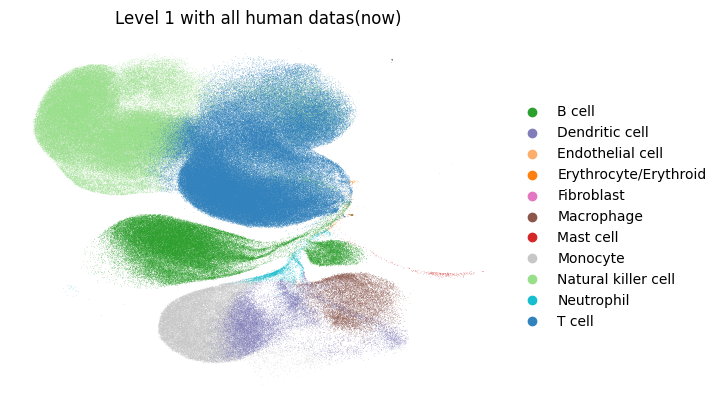

In [6]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_new,
    color='cell_type_level1_human',
    palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


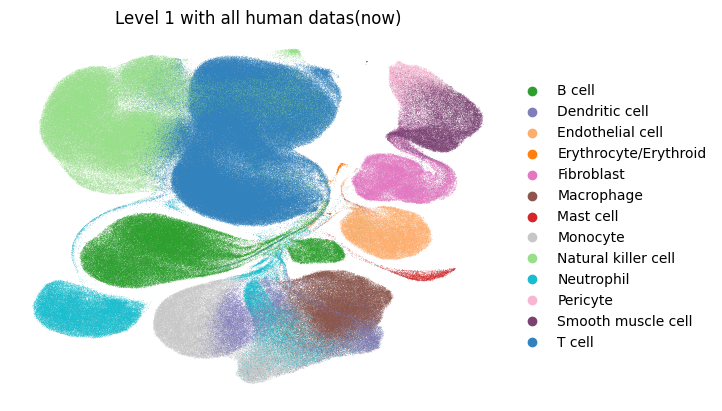

In [7]:
# Plot UMAP with custom color palette---2.0有IAISR
sc.pl.umap(
    adata_query,
    color='cell_type_level1_human',
    palette=color_palette_level1,
    size=0.5,
    show=True,
    frameon=False,
    title = "Level 1 with all human datas(now)",
    save="level1-now.pdf"
)

# Verify